Практическая работа №9, вариант 7
Интеграл: ∫ x^2*cos(x/4) dx на [2;3]
Метод прямоугольников: 4.90785305
Метод трапеций:        5.06159653
Метод Симпсона:        5.06174163
Метод Гаусса:          5.06174186
Точное значение:       5.06174185


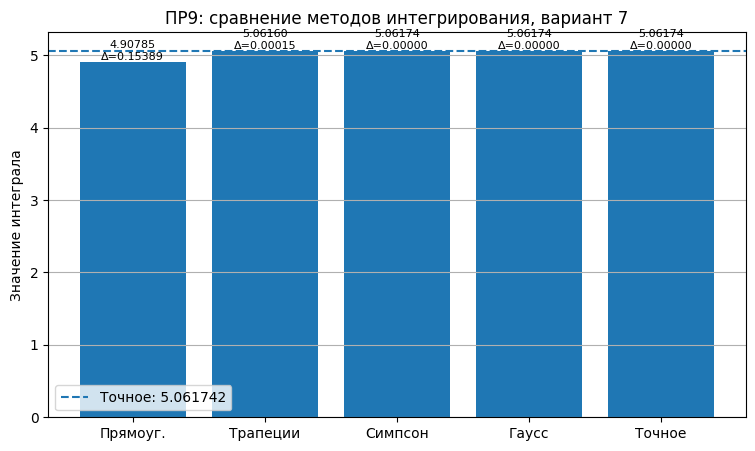

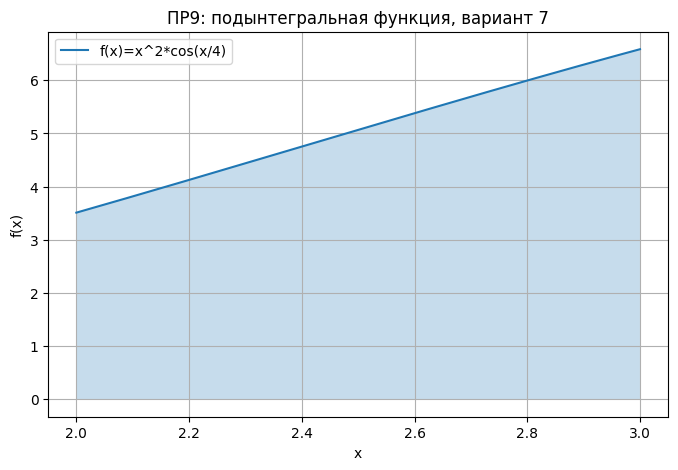

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Практическая работа №9
# Вариант 7
# f(x) = x^2 * cos(x/4), [a;b]=[2;3], n=10

a = 2.0
b = 3.0
n = 10
h = (b - a) / n

x = np.linspace(a, b, n + 1)
y = x**2 * np.cos(x / 4)

# метод прямоугольников (левые)
I_rect = h * np.sum(y[:-1])

# метод трапеций
I_trap = h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

# метод Симпсона
I_simp = (h/3) * (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-1:2]))

# формула Гаусса с двумя точками на каждом отрезке
def gauss_quad(a, b, n):
    h = (b - a) / n
    result = 0.0

    for i in range(n):
        left = a + i*h
        mid = left + h/2

        t1 = mid - h/(2*math.sqrt(3))
        t2 = mid + h/(2*math.sqrt(3))

        result += t1**2 * math.cos(t1 / 4)
        result += t2**2 * math.cos(t2 / 4)

    return h/2 * result


I_gauss = gauss_quad(a, b, n)

# точное значение через первообразную:
# F(x) = 4*x^2*sin(x/4) + 32*x*cos(x/4) - 128*sin(x/4)

F_b = 4*b**2*math.sin(b/4) + 32*b*math.cos(b/4) - 128*math.sin(b/4)
F_a = 4*a**2*math.sin(a/4) + 32*a*math.cos(a/4) - 128*math.sin(a/4)

I_exact = F_b - F_a

print("Практическая работа №9, вариант 7")
print("Интеграл: ∫ x^2*cos(x/4) dx на [2;3]")
print(f"Метод прямоугольников: {I_rect:.8f}")
print(f"Метод трапеций:        {I_trap:.8f}")
print(f"Метод Симпсона:        {I_simp:.8f}")
print(f"Метод Гаусса:          {I_gauss:.8f}")
print(f"Точное значение:       {I_exact:.8f}")

# график сравнения
methods = ["Прямоуг.", "Трапеции", "Симпсон", "Гаусс", "Точное"]
values = [I_rect, I_trap, I_simp, I_gauss, I_exact]
errors = [abs(v - I_exact) for v in values]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, values)
plt.axhline(I_exact, linestyle="--", label=f"Точное: {I_exact:.6f}")
plt.ylabel("Значение интеграла")
plt.title("ПР9: сравнение методов интегрирования, вариант 7")
plt.legend()
plt.grid(True, axis="y")

for bar, val, err in zip(bars, values, errors):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:.5f}\nΔ={err:.5f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.savefig("pr9_integral_variant7.png", dpi=150)
plt.show()
plt.close()

# график подынтегральной функции
x_dense = np.linspace(a, b, 300)
y_dense = x_dense**2 * np.cos(x_dense / 4)

plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_dense, label="f(x)=x^2*cos(x/4)")
plt.fill_between(x_dense, y_dense, alpha=0.25)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("ПР9: подынтегральная функция, вариант 7")
plt.legend()
plt.grid(True)
plt.savefig("pr9_function_variant7.png", dpi=150)
plt.show()
plt.close()